In [ ]:
import gc

gc.collect()


4

In [ ]:
#!pip install scikit-multilearn

In [ ]:
#!pip install pyarrow

In [ ]:
#!pip install scikit-multilearn

In [ ]:
#!pip install iterative-stratification

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Import Dependencies

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.multioutput import MultiOutputClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, classification_report
#from skmultilearn.model_selection import iterative_train_test_split
from sklearn.multioutput import ClassifierChain
from sklearn.metrics import classification_report, roc_auc_score
#from iterstrat.ml_stratifiers import MultilabelStratifiedKFold
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer, f1_score, recall_score, precision_score
from sklearn.metrics import (
    make_scorer, recall_score, f1_score, precision_score,
    roc_auc_score, hamming_loss, label_ranking_average_precision_score,
    multilabel_confusion_matrix, classification_report)

from xgboost import XGBClassifier
import re
from sklearn.metrics import f1_score, accuracy_score
from sklearn.metrics import label_ranking_average_precision_score
from sklearn.metrics import f1_score, accuracy_score, label_ranking_average_precision_score
import numpy as np
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score, label_ranking_average_precision_score
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


# Reading Dataset Columns

In [ ]:

csv_path = '/content/drive/MyDrive/TMU_DM_Med_Jan2025R1.csv'

#  Read only the header (column names)
df1 = pd.read_csv(csv_path, nrows=0)
raw_cols = df1.columns.to_list()
print(len(raw_cols))
raw_cols

363


['Age_at_Exam',
 'Sex',
 'sBP',
 'sBP_Date',
 'BMI',
 'BMI_Date',
 'LDL',
 'LDL_Date',
 'HDL',
 'HDL_Date',
 'A1c',
 'A1c_Date',
 'TG',
 'TG_Date',
 'FBS',
 'FBS_Date',
 'Total_Cholesterol',
 'Total_Cholesterol_Lab_Date',
 'Diabetes',
 'Depression',
 'Depression_OnsetDate',
 'HTN',
 'HTN_OnsetDate',
 'OA',
 'OA_OnsetDate',
 'COPD',
 'COPD_Date',
 'Patient_ID',
 'DM_OnsetDate',
 'DM_Onset_Revised_1YrPrior',
 '[Amputation)',
 '[Amputation_Date]',
 '[Anxiety)',
 '[Anxiety_Date]',
 '[Arrhythmia)',
 '[Arrhythmia_Date]',
 '[AtrialFibrillation)',
 '[AtrialFibrillation_Date]',
 '[Blindness)',
 '[Blindness_Date]',
 '[CABG)',
 '[CABG_Date]',
 '[CAD)',
 '[CAD_Date]',
 '[Cancer)',
 '[Cancer_Date]',
 '[Cardiomyopathy)',
 '[Cardiomyopathy_Date]',
 '[Cataract)',
 '[Cataract_Date]',
 '[CKD)',
 '[CKD_Date]',
 '[Deceased)',
 '[Deceased_Date]',
 '[Depression)',
 '[Depression_Date]',
 '[DiabeticFootUlcer)',
 '[DiabeticFootUlcer_Date]',
 '[Dialysis)',
 '[Dialysis_Date]',
 '[Enteropathy)',
 '[Enteropathy_Da

# Fixing Column Names

In [ ]:
def clean(col):
    col = re.sub(r"[\[\]\(\)]", "", col) # if replace with "" there would be two columns with name Depression
    #col = re.sub(r"[ /-]", "_", col)
    return col

clean_cols = [clean(col) for col in raw_cols]
print(len(clean_cols))
clean_cols

363


['Age_at_Exam',
 'Sex',
 'sBP',
 'sBP_Date',
 'BMI',
 'BMI_Date',
 'LDL',
 'LDL_Date',
 'HDL',
 'HDL_Date',
 'A1c',
 'A1c_Date',
 'TG',
 'TG_Date',
 'FBS',
 'FBS_Date',
 'Total_Cholesterol',
 'Total_Cholesterol_Lab_Date',
 'Diabetes',
 'Depression',
 'Depression_OnsetDate',
 'HTN',
 'HTN_OnsetDate',
 'OA',
 'OA_OnsetDate',
 'COPD',
 'COPD_Date',
 'Patient_ID',
 'DM_OnsetDate',
 'DM_Onset_Revised_1YrPrior',
 'Amputation',
 'Amputation_Date',
 'Anxiety',
 'Anxiety_Date',
 'Arrhythmia',
 'Arrhythmia_Date',
 'AtrialFibrillation',
 'AtrialFibrillation_Date',
 'Blindness',
 'Blindness_Date',
 'CABG',
 'CABG_Date',
 'CAD',
 'CAD_Date',
 'Cancer',
 'Cancer_Date',
 'Cardiomyopathy',
 'Cardiomyopathy_Date',
 'Cataract',
 'Cataract_Date',
 'CKD',
 'CKD_Date',
 'Deceased',
 'Deceased_Date',
 'Depression',
 'Depression_Date',
 'DiabeticFootUlcer',
 'DiabeticFootUlcer_Date',
 'Dialysis',
 'Dialysis_Date',
 'Enteropathy',
 'Enteropathy_Date',
 'ESRD',
 'ESRD_Date',
 'Gangrene',
 'Gangrene_Date',
 'Ga

# Fixing Duplicate column Names

In [ ]:
duplicates = pd.Series(clean_cols)[pd.Series(clean_cols).duplicated()]
print(len(duplicates))
duplicates

1


,0
54,Depression


In [ ]:
print(clean_cols[54])
clean_cols[54] = "Depression2"

Depression


# Reading Whole Dataset

In [ ]:
df = pd.read_csv(
    csv_path,
    names=clean_cols,  #  cleaned column names
    header=0, low_memory=False)

# Primary Exploration of Dataset

In [ ]:
df.shape

(808921, 363)

In [ ]:
df.head(2)

,Age_at_Exam,Sex,sBP,sBP_Date,BMI,BMI_Date,LDL,LDL_Date,HDL,HDL_Date,...,last_StartDate_b_R2_meglitinide,last_StopDate_b_R2_meglitinide,duration_b_R2_meglitinide_Days,total_b_R2_meglitinide_Records,DiagnosisText_orig,DateCreated,b_Retinopathy_combined,combined_with_Retinopathy,combined_with_b_R2_Retinopathy,combined_with_Retinopathy_and_b_R2_Retinopathy
0,69,Male,140.0,2010-03-18,26.0,2010-12-17,3.35,2010-03-06,1.03,2010-03-06,...,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0
1,56,Female,120.0,2011-11-03,24.0,2011-11-03,4.01,2011-10-04,1.84,2011-10-04,...,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0


In [ ]:
df.sample(2)

,Age_at_Exam,Sex,sBP,sBP_Date,BMI,BMI_Date,LDL,LDL_Date,HDL,HDL_Date,...,last_StartDate_b_R2_meglitinide,last_StopDate_b_R2_meglitinide,duration_b_R2_meglitinide_Days,total_b_R2_meglitinide_Records,DiagnosisText_orig,DateCreated,b_Retinopathy_combined,combined_with_Retinopathy,combined_with_b_R2_Retinopathy,combined_with_Retinopathy_and_b_R2_Retinopathy
442173,66,Male,94.0,2013-07-27,21.1,2013-06-21,1.42,2013-06-28,1.13,2013-06-28,...,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0
56784,69,Female,132.0,2010-09-02,28.4,2010-09-02,5.30,2010-12-01,1.00,2010-12-01,...,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0


# Cheking Diabetes Column for Binary Values (1, 0)

In [ ]:
df.Diabetes.sample(10)

,Diabetes
653962,1
407892,0
229391,0
780868,1
674172,1
136457,0
341772,0
724637,1
659958,1
764295,1


# Extracting Columns related to research Question

In [ ]:

# Target columns
target_columns = [
    'Retinopathy',
    'Neuropathy',
    'Nephropathy',
    'CKD',
    'ESRD',
    'DiabeticFootUlcer',
    'Amputation']

# Predictor columns: Demographics, Labs, Medication history

predictor_columns = [
    # Demographics
    'Age_at_Exam', 'Sex',

    # Vitals / Labs
    'sBP', 'BMI', 'A1c', 'FBS', 'LDL', 'HDL', 'TG', 'Total_Cholesterol',

    # Medication durations and total records (example placeholders)
    'duration_b_R2_insulin_Days', 'total_b_R2_insulin_Records',
    'duration_b_R2_statin_Days', 'total_b_R2_statin_Records',
    'duration_b_R2_diuretic_Days', 'total_b_R2_diuretic_Records',
    'duration_b_R2_ace-inhibitor_Days', 'total_b_R2_ace-inhibitor_Records',
    'duration_b_R2_sulfonylurea_Days', 'total_b_R2_sulfonylurea_Records',
    'duration_b_R2_arb_Days', 'total_b_R2_arb_Records',
    'duration_b_R2_beta-blocker_Days', 'total_b_R2_beta-blocker_Records'
]

desired_columns = predictor_columns + target_columns + ['Diabetes']


# Reading Dataset with Desired Columns

In [ ]:
# new dataframe with desired columns
ps= df[desired_columns]
ps.sample(2)

,Age_at_Exam,Sex,sBP,BMI,A1c,FBS,LDL,HDL,TG,Total_Cholesterol,...,duration_b_R2_beta-blocker_Days,total_b_R2_beta-blocker_Records,Retinopathy,Neuropathy,Nephropathy,CKD,ESRD,DiabeticFootUlcer,Amputation,Diabetes
323413,47,Male,146.0,31.2,6.3,6.2,2.98,1.32,2.93,5.63,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
666101,66,Male,125.0,28.0,5.6,5.8,1.57,1.05,1.11,3.12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1


#  Adding Patient ID to Research sub-Dataset

In [ ]:
ps['PID'] = df['Patient_ID'].values

/tmp/ipython-input-1936716745.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ps['PID'] = df['Patient_ID'].values


# Choosing the Rows with Positive Diabetes

In [ ]:
# choosing rows with Diabetes
dm = ps[ps['Diabetes'] == 1]

In [ ]:
dm.head(2)


,Age_at_Exam,Sex,sBP,BMI,A1c,FBS,LDL,HDL,TG,Total_Cholesterol,...,total_b_R2_beta-blocker_Records,Retinopathy,Neuropathy,Nephropathy,CKD,ESRD,DiabeticFootUlcer,Amputation,Diabetes,PID
574366,62,Male,110.0,32.5,6.6,5.8,1.97,0.74,0.97,3.15,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,4001000000256899
574367,48,Male,146.0,40.0,5.9,6.1,3.48,0.88,1.23,4.92,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,4001000000256044


In [ ]:
dm.columns.tolist()

['Age_at_Exam',
 'Sex',
 'sBP',
 'BMI',
 'A1c',
 'FBS',
 'LDL',
 'HDL',
 'TG',
 'Total_Cholesterol',
 'duration_b_R2_insulin_Days',
 'total_b_R2_insulin_Records',
 'duration_b_R2_statin_Days',
 'total_b_R2_statin_Records',
 'duration_b_R2_diuretic_Days',
 'total_b_R2_diuretic_Records',
 'duration_b_R2_ace-inhibitor_Days',
 'total_b_R2_ace-inhibitor_Records',
 'duration_b_R2_sulfonylurea_Days',
 'total_b_R2_sulfonylurea_Records',
 'duration_b_R2_arb_Days',
 'total_b_R2_arb_Records',
 'duration_b_R2_beta-blocker_Days',
 'total_b_R2_beta-blocker_Records',
 'Retinopathy',
 'Neuropathy',
 'Nephropathy',
 'CKD',
 'ESRD',
 'DiabeticFootUlcer',
 'Amputation',
 'Diabetes',
 'PID']

In [ ]:
dm.describe()


,Age_at_Exam,sBP,BMI,A1c,FBS,LDL,HDL,TG,Total_Cholesterol,duration_b_R2_insulin_Days,...,total_b_R2_beta-blocker_Records,Retinopathy,Neuropathy,Nephropathy,CKD,ESRD,DiabeticFootUlcer,Amputation,Diabetes,PID
count,234464.000000,234271.000000,234464.000000,187303.000000,234464.000000,232213.000000,232926.000000,232747.000000,231317.000000,88.000000,...,66571.000000,31297.000000,31297.000000,31297.000000,31297.000000,31297.000000,31297.000000,31297.000000,234464.0,2.344640e+05
mean,65.006120,131.457048,31.911564,6.806991,7.196974,2.425559,1.240572,1.773777,4.437403,710.602273,...,9.150982,0.012909,0.073489,0.008148,0.007573,0.002748,0.004154,0.020865,1.0,4.436848e+15
std,12.352098,16.797901,7.605106,1.062167,2.038046,0.995908,0.357439,1.171107,1.204832,866.558506,...,8.862490,0.112882,0.260942,0.089898,0.086692,0.052349,0.064317,0.142933,0.0,2.615696e+15
min,18.000000,40.000000,5.100000,0.530000,2.000000,0.100000,0.100000,0.100000,1.270000,0.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,1.001000e+15
25%,57.000000,120.000000,27.060000,6.200000,5.900000,1.690000,1.000000,1.080000,3.560000,0.000000,...,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,2.001000e+15
50%,66.000000,130.000000,30.699660,6.600000,6.800000,2.210000,1.190000,1.510000,4.240000,365.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,4.001000e+15
75%,74.000000,140.000000,35.200000,7.200000,7.900000,3.030000,1.420000,2.140000,5.160000,1322.000000,...,13.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,7.001001e+15
max,90.000000,260.000000,239.200000,17.800000,34.100000,9.100000,5.000000,57.340000,20.820000,3787.000000,...,59.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.000100e+16


In [ ]:
dm.info()

<class 'pandas.core.frame.DataFrame'>
Index: 234464 entries, 574366 to 808920
Data columns (total 33 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   Age_at_Exam                       234464 non-null  int64  
 1   Sex                               234464 non-null  object 
 2   sBP                               234271 non-null  float64
 3   BMI                               234464 non-null  float64
 4   A1c                               187303 non-null  float64
 5   FBS                               234464 non-null  float64
 6   LDL                               232213 non-null  float64
 7   HDL                               232926 non-null  float64
 8   TG                                232747 non-null  float64
 9   Total_Cholesterol                 231317 non-null  float64
 10  duration_b_R2_insulin_Days        88 non-null      float64
 11  total_b_R2_insulin_Records        375 non-null     f

In [ ]:
dm.shape

(234464, 33)

array([[<Axes: title={'center': 'Age_at_Exam'}>,
        <Axes: title={'center': 'sBP'}>, <Axes: title={'center': 'BMI'}>,
        <Axes: title={'center': 'A1c'}>, <Axes: title={'center': 'FBS'}>],
       [<Axes: title={'center': 'LDL'}>, <Axes: title={'center': 'HDL'}>,
        <Axes: title={'center': 'TG'}>,
        <Axes: title={'center': 'Total_Cholesterol'}>,
        <Axes: title={'center': 'duration_b_R2_insulin_Days'}>],
       [<Axes: title={'center': 'total_b_R2_insulin_Records'}>,
        <Axes: title={'center': 'duration_b_R2_statin_Days'}>,
        <Axes: title={'center': 'total_b_R2_statin_Records'}>,
        <Axes: title={'center': 'duration_b_R2_diuretic_Days'}>,
        <Axes: title={'center': 'total_b_R2_diuretic_Records'}>],
       [<Axes: title={'center': 'duration_b_R2_ace-inhibitor_Days'}>,
        <Axes: title={'center': 'total_b_R2_ace-inhibitor_Records'}>,
        <Axes: title={'center': 'duration_b_R2_sulfonylurea_Days'}>,
        <Axes: title={'center': 'total

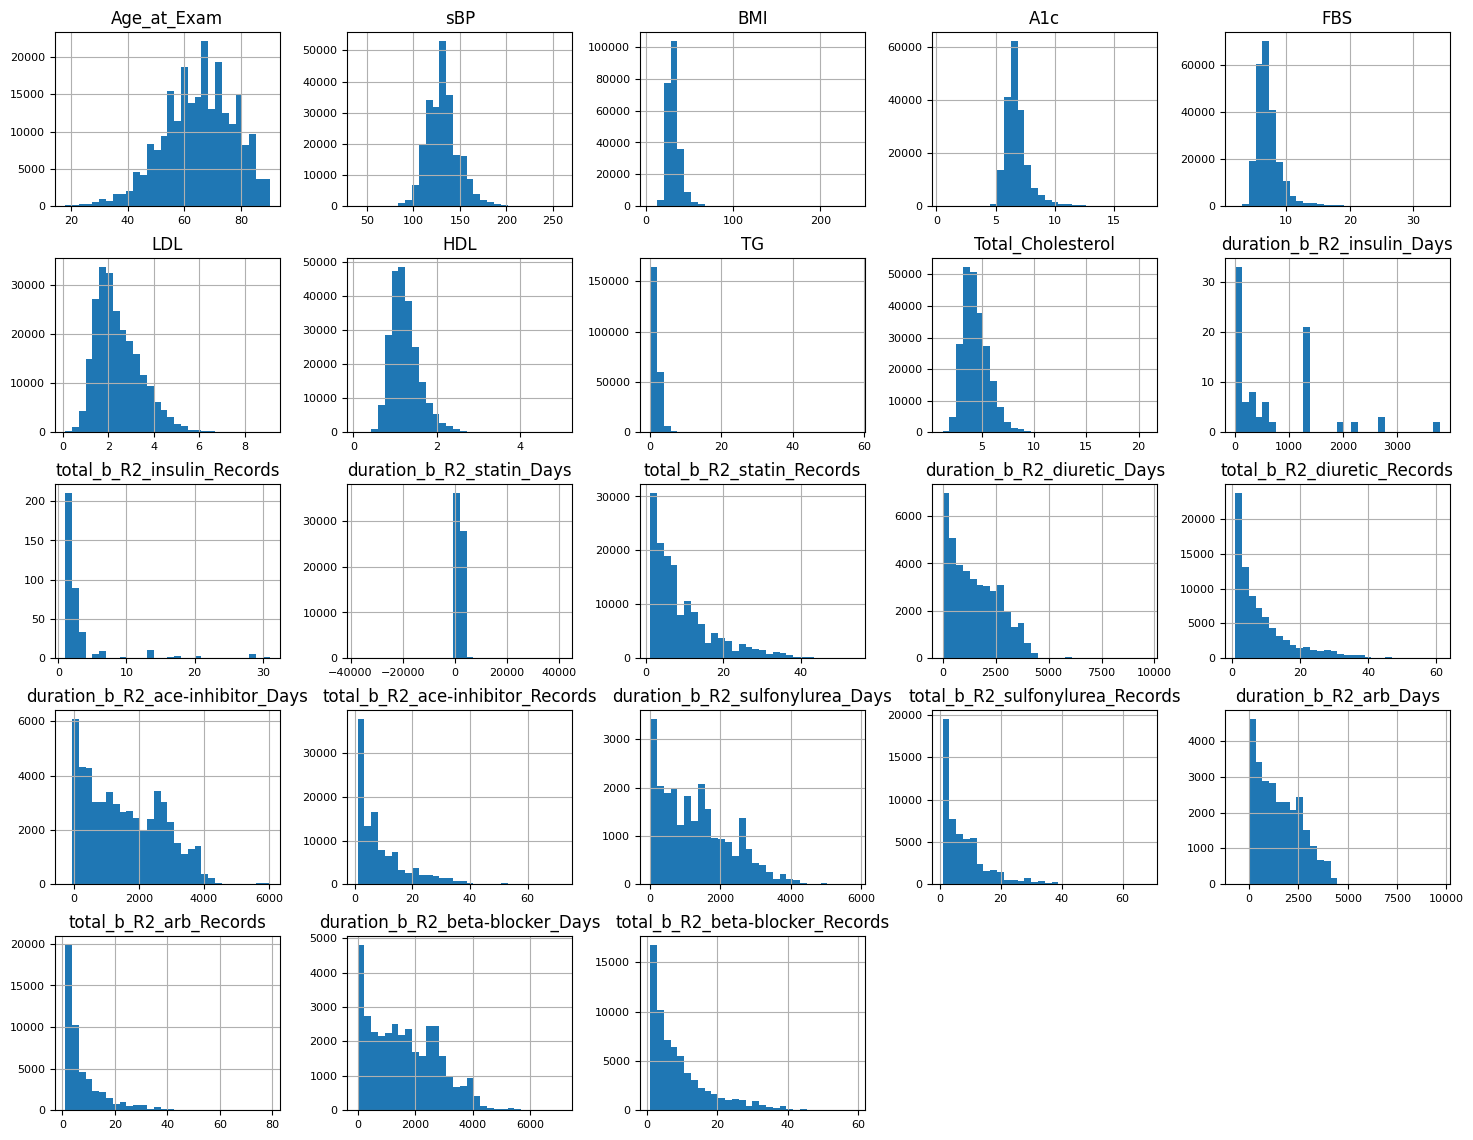

In [ ]:
dm[predictor_columns].hist(figsize=(18, 14), bins=30, xlabelsize=8, ylabelsize=8)

array([[<Axes: title={'center': 'Retinopathy'}>,
        <Axes: title={'center': 'Neuropathy'}>,
        <Axes: title={'center': 'Nephropathy'}>],
       [<Axes: title={'center': 'CKD'}>,
        <Axes: title={'center': 'ESRD'}>,
        <Axes: title={'center': 'DiabeticFootUlcer'}>],
       [<Axes: title={'center': 'Amputation'}>, <Axes: >, <Axes: >]],
      dtype=object)

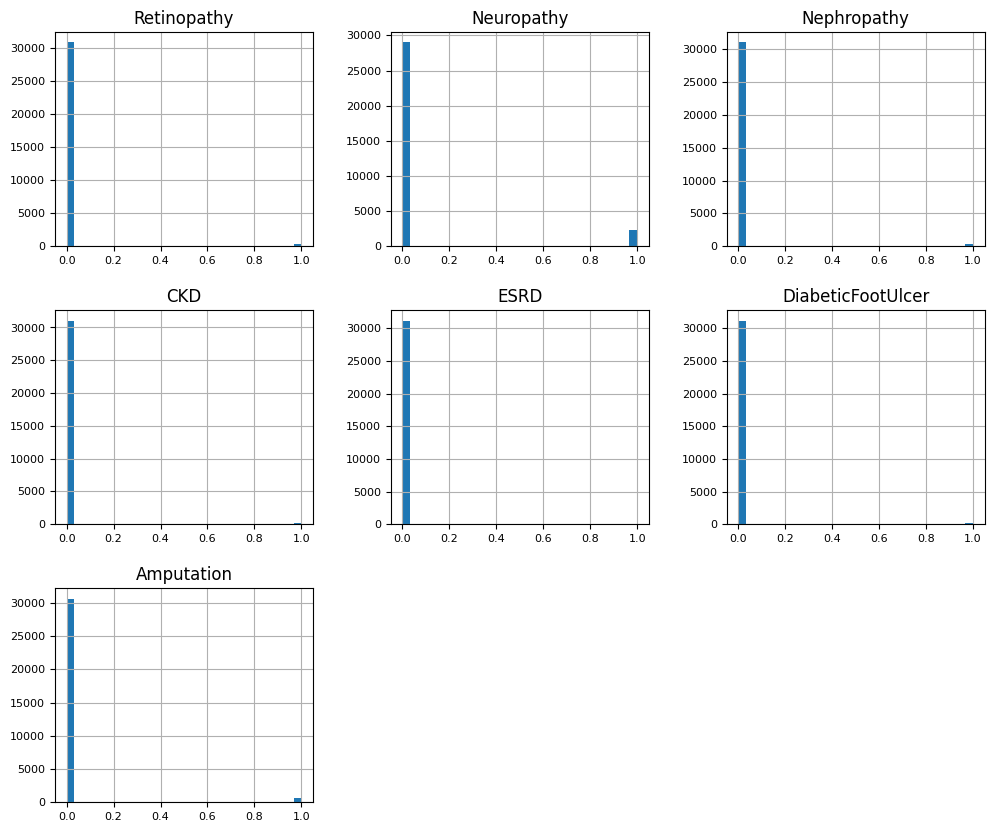

In [ ]:
dm[target_columns].hist(figsize=(12, 10), bins=30, xlabelsize=8, ylabelsize=8)

# Filtering Columns Needed for Train
 (Drop Diabetes column)

In [ ]:
dm = dm.drop(columns='Diabetes')

# Patient-level Search

In [ ]:
dm['PID'].duplicated().sum()

np.int64(208544)

# Unique Patients

In [ ]:
print("Unique patients:", dm['PID'].nunique())

Unique patients: 25920


# New Dataset Dimensions

In [ ]:
dm.shape

(234464, 32)

# The  data is visit-level.

## with the CPCSSN dataset, we are dealing with Longitudinal Data (the same patient appearing multiple times over years).

### Using Aggregation + GroupShuffleSplit.

# Aggregate dataset based on the patient ID


 Implementation Checklist Use :

 median for labs where you suspect outliers (BMI, HDL, TG).

 Use std (Standard Deviation) for A1c and sBP specifically; this is the "gold" predictor for diabetes complications.

 Use last to provide the model with the patient's "current" state before the end of the study.



* A1c	std & max	Glycemic Variability (the "swings") is a better predictor of microvascular damage (Retinopathy/Neuropathy) than a steady average.


* sBP	max & mean	High "peaks" in blood pressure cause immediate mechanical damage to kidney filters (CKD/ESRD) and eye vessels.

* BMI	median	BMI doesn't change as fast as blood sugar. median filters out the data entry errors common in busy primary care clinics.

* LDL max (Cardiovascular events), the highest cholesterol level ever reached is often what triggered the plaque buildup in the first place.

In [ ]:
# Perform the aggregation
dm_patient = dm.groupby('PID').agg({
    'Age_at_Exam': 'max',
    'Sex': 'first',

    # Vitals & Labs (Adding Mean and Max, ... for better prediction)
    # Vitals & Labs: Mean is good, but 'Max' or 'STD' captures "uncontrolled" spikes

    # Captures the "Typical" state (Median), "Worst" state (Max), and "Recent" state (Last)
    'A1c': ['median', 'max', 'std', 'last'],
    'sBP': ['mean', 'max', 'std', 'last'],
    'BMI': ['median', 'last'],

    # Metabolic profile
    'LDL': ['median', 'max'],
    'HDL': ['median'],
    'TG': ['median', 'max'],
    'Total_Cholesterol': ['max'],


    # Medications (Summing total exposure)
    'duration_b_R2_insulin_Days': 'sum',
    'total_b_R2_insulin_Records': 'sum',
    'duration_b_R2_statin_Days': 'sum',
    'total_b_R2_statin_Records': 'sum',
    'duration_b_R2_diuretic_Days': 'sum',
    'total_b_R2_diuretic_Records': 'sum',
    'duration_b_R2_ace-inhibitor_Days': 'sum',
    'total_b_R2_ace-inhibitor_Records': 'sum',
    'duration_b_R2_sulfonylurea_Days': 'sum',
    'total_b_R2_sulfonylurea_Records': 'sum',
    'duration_b_R2_arb_Days': 'sum',
    'total_b_R2_arb_Records': 'sum',
    'duration_b_R2_beta-blocker_Days': 'sum',
    'total_b_R2_beta-blocker_Records': 'sum',

    # Labels (Max ensures 1 if they ever had the complication)
    'Retinopathy': 'max',
    'Neuropathy': 'max',
    'Nephropathy': 'max',
    'CKD': 'max',
    'ESRD': 'max',
    'DiabeticFootUlcer': 'max',
    'Amputation': 'max'
})


# Fill missing values with 0
dm_patient = dm_patient.fillna(0)

# Flatten MultiIndex (Crucial!)
dm_patient.columns = ['_'.join(col).strip() if isinstance(col, tuple) else col for col in dm_patient.columns]

# Flatten the index so PID is a column again
dm_patient = dm_patient.reset_index()

In [ ]:
dm_patient.head(2)

,PID,Age_at_Exam_max,Sex_first,A1c_median,A1c_max,A1c_std,A1c_last,sBP_mean,sBP_max,sBP_std,...,total_b_R2_arb_Records_sum,duration_b_R2_beta-blocker_Days_sum,total_b_R2_beta-blocker_Records_sum,Retinopathy_max,Neuropathy_max,Nephropathy_max,CKD_max,ESRD_max,DiabeticFootUlcer_max,Amputation_max
0,1001000000001150,61,Male,6.8,9.3,0.770467,6.8,126.666667,146.0,9.612793,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1001000000001343,72,Female,0.0,0.0,0.000000,0.0,132.260870,146.0,7.794038,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
dm_patient.describe()

,PID,Age_at_Exam_max,A1c_median,A1c_max,A1c_std,A1c_last,sBP_mean,sBP_max,sBP_std,sBP_last,...,total_b_R2_arb_Records_sum,duration_b_R2_beta-blocker_Days_sum,total_b_R2_beta-blocker_Records_sum,Retinopathy_max,Neuropathy_max,Nephropathy_max,CKD_max,ESRD_max,DiabeticFootUlcer_max,Amputation_max
count,2.592000e+04,25920.000000,25920.000000,25920.000000,25920.000000,25920.000000,25920.000000,25920.000000,25920.000000,25920.000000,...,25920.000000,25920.000000,25920.000000,25920.00000,25920.000000,25920.00000,25920.000000,25920.000000,25920.000000,25920.000000
mean,4.427282e+15,63.748958,5.965443,6.365704,0.279761,5.986719,130.732159,144.401775,9.393234,130.772917,...,14.570756,2216.905826,23.502701,0.00108,0.007060,0.00108,0.000617,0.000116,0.000309,0.001466
std,2.629372e+15,13.487742,2.504496,2.777648,0.451099,2.545872,13.121610,19.003290,6.415789,16.718084,...,83.251182,10974.394639,106.496080,0.03285,0.083729,0.03285,0.024838,0.010758,0.017566,0.038262
min,1.001000e+15,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,-41.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
25%,2.001000e+15,55.000000,5.900000,6.100000,0.000000,5.900000,122.333333,131.000000,5.270463,120.000000,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
50%,4.001000e+15,65.000000,6.450000,6.700000,0.141422,6.400000,130.000000,142.000000,9.394994,130.000000,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
75%,7.001001e+15,74.000000,7.100000,7.600000,0.355214,7.100000,138.000000,156.000000,13.140364,140.000000,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
max,1.000100e+16,90.000000,16.400000,17.800000,5.270463,16.900000,240.000000,260.000000,79.195959,240.000000,...,2806.000000,304029.000000,2616.000000,1.00000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000


In [ ]:
dm_patient.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25920 entries, 0 to 25919
Data columns (total 40 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   PID                                   25920 non-null  int64  
 1   Age_at_Exam_max                       25920 non-null  int64  
 2   Sex_first                             25920 non-null  object 
 3   A1c_median                            25920 non-null  float64
 4   A1c_max                               25920 non-null  float64
 5   A1c_std                               25920 non-null  float64
 6   A1c_last                              25920 non-null  float64
 7   sBP_mean                              25920 non-null  float64
 8   sBP_max                               25920 non-null  float64
 9   sBP_std                               25920 non-null  float64
 10  sBP_last                              25920 non-null  float64
 11  BMI_median     

In [ ]:
# Not preffered after aggregation

'''from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)'''


'from sklearn.model_selection import GroupShuffleSplit\n\ngss = GroupShuffleSplit(\n    n_splits=1,\n    test_size=0.2,\n    random_state=42\n)'

In [ ]:
int(dm_patient['PID'].duplicated().sum())


0

#### Alternative approach (better for prediction timing)

Instead of aggregating mean, using LAST observation before outcome

This is called:

Index date design

Used in:

• Lancet Digital Health
• Nature Medicine
• CPCSSN publications

In [ ]:
dm.groupby('PID').size().value_counts()


,count
1,3589
2,3177
3,2511
4,2257
5,1788
...,...
143,1
178,1
389,1
151,1


# Define features and targets (No Leakage)

In [ ]:
# Separate Features and Targets

target_columns = ['Retinopathy', 'Neuropathy', 'Nephropathy', 'CKD', 'ESRD', 'DiabeticFootUlcer', 'Amputation']

target_cols = [col + '_max' for col in target_columns]
X = dm_patient.drop(columns=['PID'] + target_cols)
y = dm_patient[target_cols]



In [ ]:
print(X.shape)
print(y.shape)

(25920, 32)
(25920, 7)


In [ ]:
X.shape[0] == y.shape[0]

True

In [ ]:
print(type(X), type(y))

<class 'pandas.core.frame.DataFrame'> <class 'pandas.core.frame.DataFrame'>


In [ ]:
X = X.values
y = y.values

# Train–test split (patient-level)

## LogicReason:

Standard random splitting often results in "label sparsity" in the test set, where rare but critical complications (like Amputation or ESRD) may not appear at all, making the model evaluation impossible.

## Strategy:

 We use Iterative Stratification on the aggregated patient-level data. This ensures the complex combinations of multiple complications are distributed proportionally ($70/15/15$) across all sets, maintaining the biological integrity of the cohort.

#### Iterative stratification  : 70 / 15 / 15 patient-level split


Pattern Preservation: iterative_train_test_split (Result A) doesn't just look at one label at a time. It tries to ensure that if someone has the "Triple Threat" (Retinopathy + Neuropathy + Nephropathy), that specific combination exists in both your training and testing sets.



## Simple Split for memory sake

### Step 1: Train (70%) vs Temp (30%)
### Step 2:  Split temp → 15% validation / 15% test


In [ ]:


# Step 1: 70% Train, 30% Temporary (which will become 15% Val and 15% Test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42
)

# Step 2: Split the 30% Temp into two equal halves (15% each)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42
)

# Validation: Verify proportion of complications across sets
print(f"Train size: {len(X_train)} | Val size: {len(X_val)} | Test size: {len(X_test)}")
# print("Check stratification (Retinopathy %):", y_train[:,0].mean(), y_test[:,0].mean())

Train size: 18144 | Val size: 3888 | Test size: 3888


In [ ]:
# Validation Check
# Ensure the rarest labels (like Amputation) actually appear in the Test set
# axis=0 tells it to sum each column individually
print(y_test.sum(axis=0))

[ 6. 22.  5.  2.  1.  1.  3.]


In [ ]:
# or Convert back to DataFrame using your list of target columns
y_test_df = pd.DataFrame(y_test, columns=target_cols)

#  .sum() will give you the 7 distinct counts
print(y_test_df.sum())

Retinopathy_max           6.0
Neuropathy_max           22.0
Nephropathy_max           5.0
CKD_max                   2.0
ESRD_max                  1.0
DiabeticFootUlcer_max     1.0
Amputation_max            3.0
dtype: float64


In [ ]:


print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

Train: 18144 | Val: 3888 | Test: 3888


# Preprocessing (nulls + encoding)





In [ ]:
#  'Sex' is  categorical column; all others are numeric labs/vitals
numeric_cols = pd.DataFrame(X_val).select_dtypes(include=['int32', 'float32']).columns
categorical_cols = pd.DataFrame(X_val).select_dtypes(include=['object', 'category']).columns


# Building the Preprocessor, No scaling needed for XGBoost!
preprocessor = ColumnTransformer(
    transformers=[
        ('num', SimpleImputer(strategy='median'), numeric_cols),
        ('cat', Pipeline([
            ('impute', SimpleImputer(strategy='most_frequent')),
            ('encode', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), categorical_cols)
    ])

# Model Structure: Multi-Output XGBoost

In [ ]:
xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    tree_method='hist',
    n_estimators=50,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=21,
    verbosity=0, # Silences warnings to save console memory
    n_jobs = -1
)

In [ ]:
model = MultiOutputClassifier(xgb, n_jobs=-1)

#### chain = ClassifierChain(...)

The Role: This is the another Strategy for Multi-Label prediction. But memory consuming.

* Because I have 7 different complications, a regular XGBoost doesn't know how to handle them all at once.

* The Classifier Chain links 7 XGBoost models together. The first model predicts one complication, then passes that result to the second model as a "hint."

In [ ]:
# Wrap it in a Classifier Chain (for co-occurrence)
# chain = ClassifierChain(xgb, order='random', random_state=42)

# pipeline

In [ ]:
pipeline = Pipeline([
    ('prep', preprocessor),
    ('clf', model)])


# Creat a Subset of Train Data

In [ ]:
subset_size = 6000
# Create stratification label (at least one complication vs none)
train_stratify_label = (y_train.sum(axis=1) > 0).astype(int)

# Generate stratified indices
rng = np.random.RandomState(42)

subset_idx = []

for label in np.unique(train_stratify_label):

    label_idx = np.where(train_stratify_label == label)[0]

    n_label_subset = int(subset_size * len(label_idx) / len(train_stratify_label))

    subset_idx.extend(
        rng.choice(label_idx, n_label_subset, replace=False)
    )

subset_idx = np.array(subset_idx)

# Apply subset
X_train_subset = X_train[subset_idx]
y_train_subset = y_train[subset_idx]

print(X_train_subset.shape)
print(y_train_subset.shape)

(5999, 32)
(5999, 7)


# 3-fold stratified CV (TRAINING ONLY)

using this approach because:

 memory is tight and I can’t run MultilabelStratifiedKFold


With large dataset like CPCSSN  iterative stratification consumes too much RAM



In [ ]:
from sklearn.model_selection import StratifiedKFold
import gc
from sklearn.metrics import f1_score, recall_score, hamming_loss, roc_auc_score, label_ranking_average_precision_score



scores = []
conf_matrices = []

# Create stratification labels for multi-label (at least one complication vs none)

train_stratify_label = (y_train.sum(axis=1) > 0).astype(int)
train_stratify_subset = (y_train_subset.sum(axis=1) > 0).astype(int)

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

In [ ]:

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_subset, train_stratify_subset)):

    print(f"\n=========== Fold {fold+1} ===========")


    # Split data for this fold

    X_tr = X_train_subset[train_idx]
    X_val = X_train_subset[val_idx]

    y_tr = y_train_subset[train_idx]
    y_val = y_train_subset[val_idx]


    # TRAIN pipeline
    pipeline.fit(X_tr, y_tr)

    # PREDICT probabilities
    y_prob_list = pipeline.predict_proba(X_val)

    y_prob_matrix = np.column_stack([p[:, 1] for p in y_prob_list])

    # Binary predictions
    y_pred_matrix = (y_prob_matrix >= 0.5).astype(int)

    # Metrics
    f1 = f1_score(y_val, y_pred_matrix, average='macro')
    recall = recall_score(y_val, y_pred_matrix, average='macro')
    hamming = hamming_loss(y_val, y_pred_matrix)

    auc_macro = roc_auc_score(y_val, y_prob_matrix, average='macro')
    auc_micro = roc_auc_score(y_val, y_prob_matrix, average='micro')

    lrap = label_ranking_average_precision_score(y_val, y_prob_matrix)

    print(f"F1-score: {f1:.3f}")
    print(f"Recall: {recall:.3f}")
    print(f"Hamming: {hamming:.3f}")
    print(f"ROC-AUC macro: {auc_macro:.3f}")
    print(f"ROC-AUC micro: {auc_micro:.3f}")
    print(f"LRAP: {lrap:.3f}")

    scores.append({
        "f1_macro": f1,
        "recall_macro": recall,
        "hamming": hamming,
        "roc_auc_macro": auc_macro,
        "roc_auc_micro": auc_micro,
        "lrap": lrap
    })

    # Confusion matrix
    cm_per_label = multilabel_confusion_matrix(y_val, y_pred_matrix)

    conf_matrices.append(cm_per_label)

    print("\nConfusion matrices:")
    print(cm_per_label)


=========== Fold 1 ===========
F1-score: 0.000
Recall: 0.000
Hamming: 0.002
ROC-AUC macro: 0.514
ROC-AUC micro: 0.738
LRAP: 0.996

Confusion matrices:
[[[1998    0]
  [   2    0]]

 [[1984    0]
  [  16    0]]

 [[1999    0]
  [   1    0]]

 [[1999    0]
  [   1    0]]

 [[1999    0]
  [   1    0]]

 [[1999    0]
  [   1    0]]

 [[1997    0]
  [   3    0]]]

=========== Fold 2 ===========


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


F1-score: 0.000
Recall: 0.000
Hamming: 0.002
ROC-AUC macro: nan
ROC-AUC micro: 0.687
LRAP: 0.995

Confusion matrices:
[[[1998    0]
  [   2    0]]

 [[1989    0]
  [  11    0]]

 [[1997    0]
  [   3    0]]

 [[1999    0]
  [   1    0]]

 [[2000    0]
  [   0    0]]

 [[1998    0]
  [   2    0]]

 [[1994    0]
  [   6    0]]]

=========== Fold 3 ===========
F1-score: 0.000
Recall: 0.000
Hamming: 0.002
ROC-AUC macro: nan
ROC-AUC micro: 0.800
LRAP: 0.997

Confusion matrices:
[[[1997    0]
  [   2    0]]

 [[1980    0]
  [  19    0]]

 [[1999    0]
  [   0    0]]

 [[1998    0]
  [   1    0]]

 [[1999    0]
  [   0    0]]

 [[1999    0]
  [   0    0]]

 [[1998    0]
  [   1    0]]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that ca

# Evaluation Scores

In [ ]:
print("\n\n=========== FINAL RESULTS ===========")

mean_f1 = np.mean([s["f1_macro"] for s in scores])
mean_recall = np.mean([s["recall_macro"] for s in scores])
mean_hamming = np.mean([s["hamming"] for s in scores])
mean_auc_macro = np.mean([s["roc_auc_macro"] for s in scores])
mean_auc_micro = np.mean([s["roc_auc_micro"] for s in scores])
mean_lrap = np.mean([s["lrap"] for s in scores])

best_auc_macro = np.max([s["roc_auc_macro"] for s in scores])
best_auc_micro = np.max([s["roc_auc_micro"] for s in scores])

print("\nAverage Metrics:")
print(f"Mean F1 (macro): {mean_f1:.3f}")
print(f"Mean Recall (macro): {mean_recall:.3f}")
print(f"Mean Hamming: {mean_hamming:.3f}")
print(f"Mean ROC-AUC (macro): {mean_auc_macro:.3f}")
print(f"Mean ROC-AUC (micro): {mean_auc_micro:.3f}")
print(f"Mean LRAP: {mean_lrap:.3f}")

print("\nBest ROC-AUCs:")
print(f"Best ROC-AUC (macro): {best_auc_macro:.3f}")
print(f"Best ROC-AUC (micro): {best_auc_micro:.3f}")



=========== FINAL RESULTS ===========

Average Metrics:
Mean F1 (macro): 0.000
Mean Recall (macro): 0.000
Mean Hamming: 0.002
Mean ROC-AUC (macro): nan
Mean ROC-AUC (micro): 0.742
Mean LRAP: 0.996

Best ROC-AUCs:
Best ROC-AUC (macro): nan
Best ROC-AUC (micro): 0.800


# Train Final Model

In [ ]:
pipeline.fit(X_train_subset, y_train_subset)

gc.collect()


# Predict Test Set

In [ ]:
X_test_prepared = preprocessor.transform(X_test)

y_prob_test = multi_xgb.predict_proba(X_test_prepared)
#y_prob_matrix_test = np.column_stack([p[:, 1] for p in y_prob_test])


In [ ]:
# Binary predictions directly
y_pred_test = multi_xgb.predict(X_test_prepared)


In [ ]:

# Metrics using predicted classes only
f1_test = f1_score(y_test, y_pred_test, average='macro')
hamming_test = hamming_loss(y_test, y_pred_matrix_test)
cm_test = multilabel_confusion_matrix(y_test, y_pred_matrix_test)

In [ ]:

y_prob_matrix_test = np.array([p[:,1] for p in y_prob_test]).T

print(y_prob_matrix_test.shape)

(3888, 7)


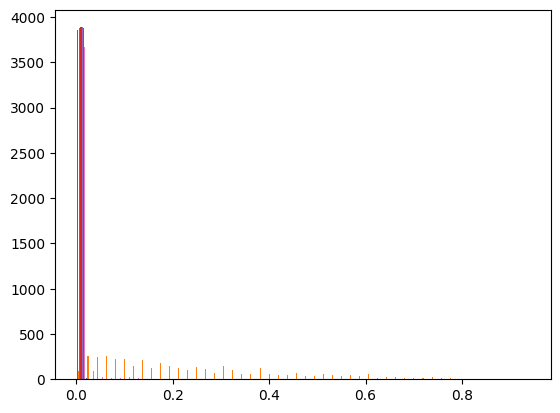

In [ ]:
plt.hist(y_prob_matrix_test[:,0], bins=50)
plt.show()

# Confusion Matrix on the test Data

In [ ]:
from sklearn.metrics import confusion_matrix

y_test_pred = pipeline.predict(X_test)

cm_test = confusion_matrix(
    y_test.ravel(),
    y_test_pred.ravel()
)

print(cm_test)

NameError: name 'pipeline' is not defined

# Confusion Matrix Heatmap (per complication)

In [ ]:
y[0]

array([0., 0., 0., 0., 0., 0., 0.])

In [ ]:
y_prob_matrix_test.shape

(3888, 7)

In [ ]:
y_test.shape

(3888, 7)

In [ ]:
print(np.min(y_prob_matrix_test[:10,0]), np.max(y_prob_matrix_test[:10,0]))
print(np.unique(y_prob_matrix_test[:10,0]))

6.756911e-05 0.0020036078
[6.7569112e-05 1.4195094e-04 3.3501300e-04 3.3716441e-04 4.0546746e-04
 5.3627382e-04 5.8045535e-04 1.3759814e-03 1.8412127e-03 2.0036078e-03]


In [ ]:
print("Min prob:", np.min(y_prob_matrix_test[:,0]))
print("Max prob:", np.max(y_prob_matrix_test[:,0]))
print("Sample probs:", y_prob_matrix_test[:20,0])

Min prob: 6.6598164e-05
Max prob: 0.013960475
Sample probs: [3.3716441e-04 6.7569112e-05 1.4195094e-04 5.8045535e-04 3.3501300e-04
 1.8412127e-03 4.0546746e-04 5.3627382e-04 1.3759814e-03 2.0036078e-03
 3.5379429e-03 2.0823244e-04 8.2896380e-03 5.0426793e-04 3.9187898e-03
 2.5861126e-03 2.5652637e-04 4.3161830e-04 1.2422251e-04 1.4763970e-03]


# Check model performance

If all probabilities are tiny (<0.01), the model may not be learning positive class at all.

In [ ]:
y_prob_matrix_test = np.column_stack([p[:,1] for p in y_prob_test])
print(y_prob_matrix_test.shape)  # (n_samples, n_labels)


pos = np.sum(y_val[:,0])
neg = y_val.shape[0] - pos
scale = neg / pos
print(pos, neg, scale)

(3888, 7)
2.0 3886.0 1943.0


In [ ]:
for i, label in enumerate(label_names):
    print(label)
    print("Min prob:", np.min(y_prob_matrix_test[:,i]))
    print("Max prob:", np.max(y_prob_matrix_test[:,i]))
    print("Unique probs (sample):", np.unique(y_prob_matrix_test[:,i])[:10])

Retinopathy
Min prob: 6.6598164e-05
Max prob: 0.013960475
Unique probs (sample): [6.65981643e-05 6.75691117e-05 9.32152398e-05 9.45741995e-05
 1.02772014e-04 1.04270286e-04 1.17968681e-04 1.19688477e-04
 1.22437588e-04 1.24194688e-04]
Neuropathy
Min prob: 0.00043704684
Max prob: 0.38137951
Unique probs (sample): [0.00043705 0.00045201 0.00046958 0.00050503 0.00052087 0.00053001
 0.0005641  0.00056564 0.00059029 0.00059141]
Nephropathy
Min prob: 1.9738287e-05
Max prob: 0.0235835
Unique probs (sample): [1.9738287e-05 2.2452603e-05 2.2756876e-05 2.5886284e-05 2.6049134e-05
 2.6620586e-05 2.7421333e-05 2.9631263e-05 3.0032817e-05 3.0281295e-05]
CKD
Min prob: 0.00017296131
Max prob: 0.0013231692
Unique probs (sample): [0.00017296 0.00020515 0.00021577 0.00025592 0.00027198 0.00032259
 0.0003393  0.00040242 0.000569   0.00067483]
ESRD
Min prob: 0.00016669442
Max prob: 0.00016669442
Unique probs (sample): [0.00016669]
DiabeticFootUlcer
Min prob: 0.00016533733
Max prob: 0.0010367952
Unique pro

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


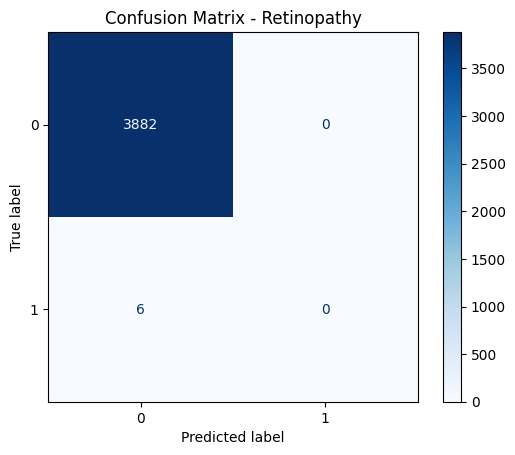

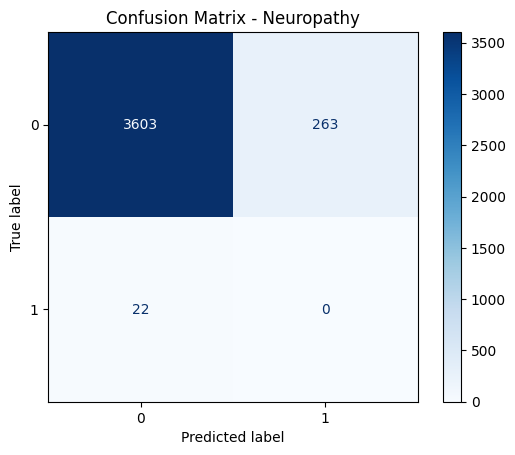

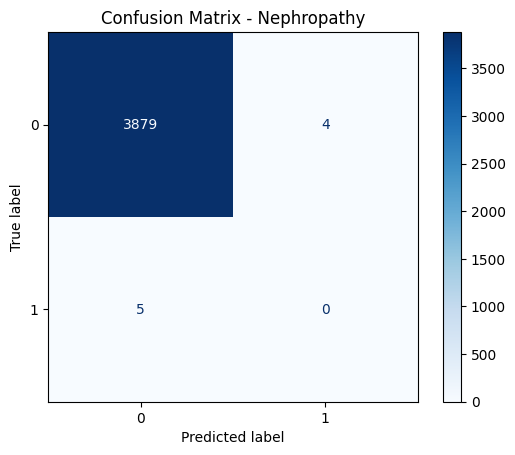

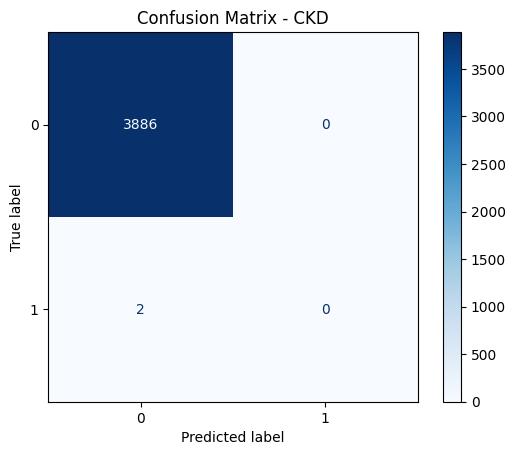

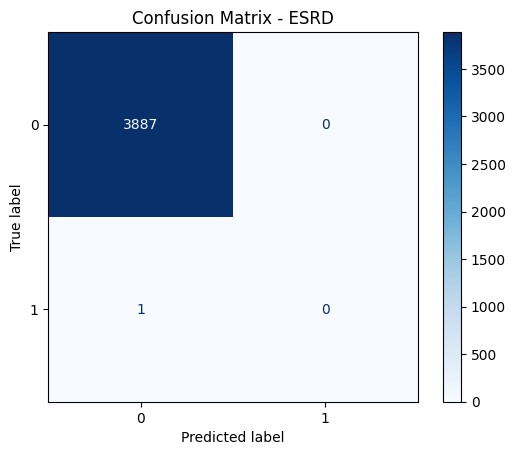

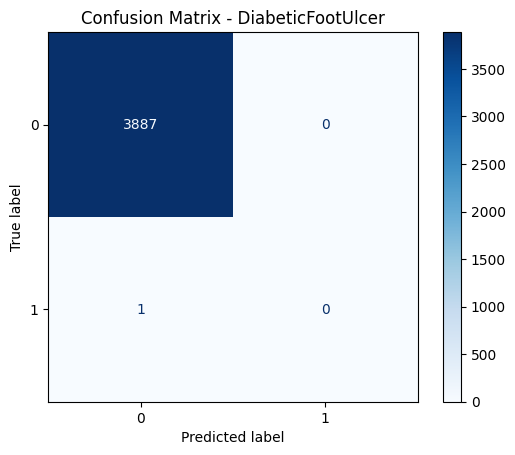

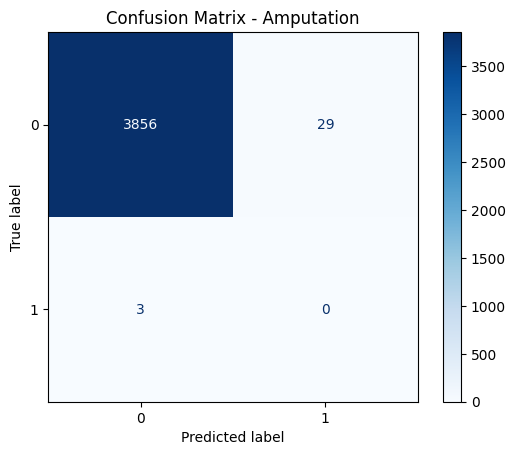

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# y_test and y_pred must be numpy arrays
y_test_np = y_test
y_prob_matrix_test  # already NumPy from pipeline.predict

# complication names
label_names = target_columns

# Convert probabilities to binary
threshold = 0.02
y_pred_np_binary = (y_prob_matrix_test >= threshold).astype(int)
print(y_pred_np_binary[:20,0])

n_labels = y_test_np.shape[1]

for i, label in enumerate(label_names):
    # Compute confusion matrix
    cm = confusion_matrix(y_test_np[:, i], y_pred_np_binary[:, i])

    # Display it
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1])
    disp.plot(cmap=plt.cm.Blues)

    plt.title(f"Confusion Matrix - {label}")
    plt.show()



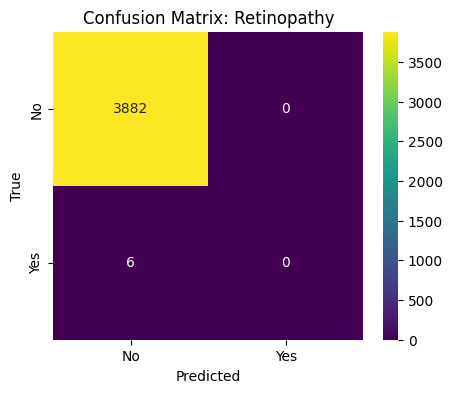

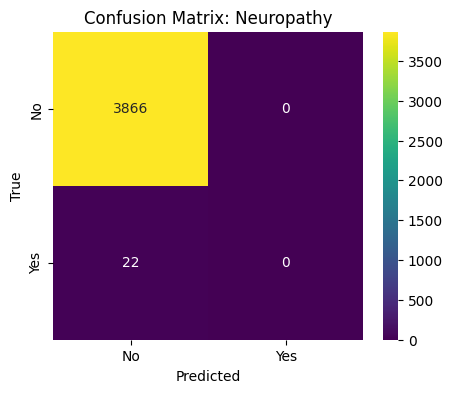

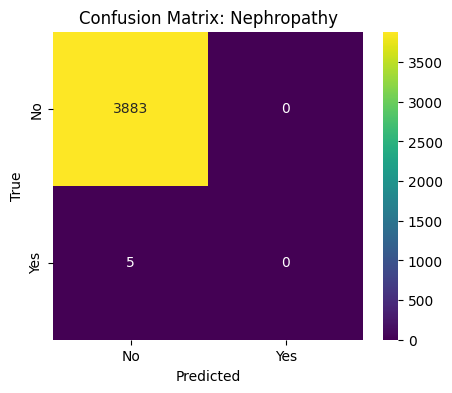

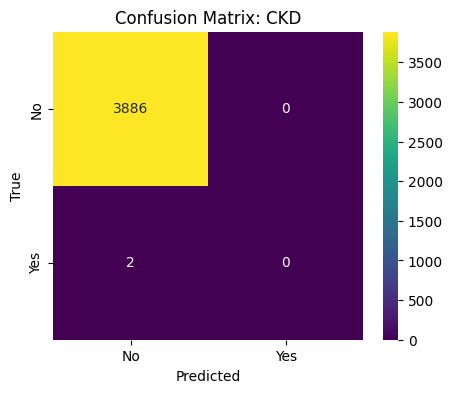

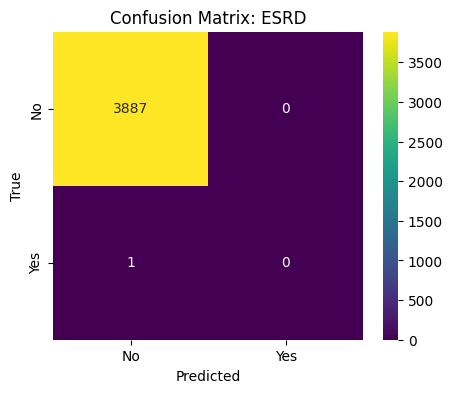

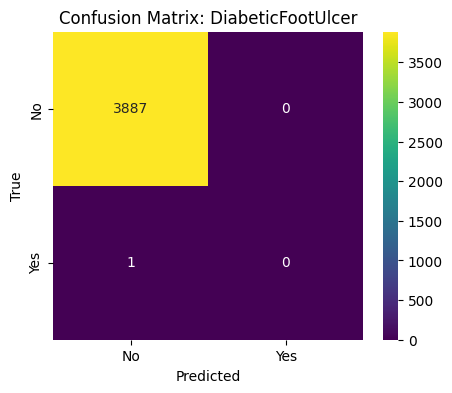

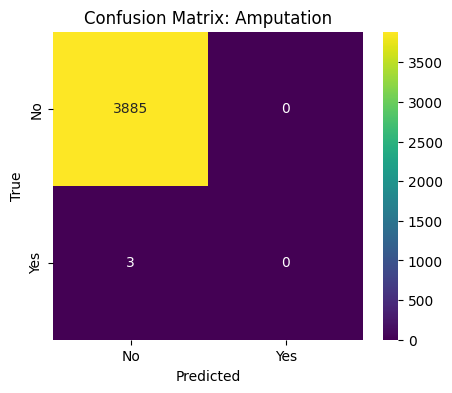

In [ ]:
# y_test and y_pred must be numpy arrays
y_test_np = y_test
y_pred_np = y_test_pred  # already NumPy from pipeline.predict

# complication names
label_names = target_columns

cm = multilabel_confusion_matrix(y_test_np, y_pred_np)


for i, label in enumerate(label_names):

    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm[i],
        annot=True,
        fmt="d",
        cmap="viridis",
        xticklabels=["No", "Yes"],
        yticklabels=["No", "Yes"]
    )

    plt.title(f"Confusion Matrix: {label}")
    plt.ylabel("True")
    plt.xlabel("Predicted")

    plt.show()

In [ ]:
# Create confusion matrix per target
for i, target in enumerate(target_columns):
    cm = confusion_matrix(y_test[:, i], y_test_pred[:, i])
    print(f"Confusion Matrix for {target}:\n{cm}\n")

Confusion Matrix for Retinopathy:
[[3882    0]
 [   6    0]]

Confusion Matrix for Neuropathy:
[[3866    0]
 [  22    0]]

Confusion Matrix for Nephropathy:
[[3883    0]
 [   5    0]]

Confusion Matrix for CKD:
[[3886    0]
 [   2    0]]

Confusion Matrix for ESRD:
[[3887    0]
 [   1    0]]

Confusion Matrix for DiabeticFootUlcer:
[[3887    0]
 [   1    0]]

Confusion Matrix for Amputation:
[[3885    0]
 [   3    0]]



# Compute PR-AUC score

In [ ]:
from sklearn.metrics import average_precision_score

pr_auc_macro = average_precision_score(
    y_test,
    y_test_pred,
    average='macro'
)

print("PR-AUC Macro:", pr_auc_macro)

PR-AUC Macro: 0.0014697236919459142


# Compute PR-AUC per label

In [ ]:
from sklearn.metrics import average_precision_score

for i in range(y_test.shape[1]):

    score = average_precision_score(
        y_test[:, i],
        y_test_pred[:, i]
    )

    print(f"Label {i} PR-AUC:", score)

Label 0 PR-AUC: 0.0015432098765432098
Label 1 PR-AUC: 0.00565843621399177
Label 2 PR-AUC: 0.001286008230452675
Label 3 PR-AUC: 0.00051440329218107
Label 4 PR-AUC: 0.000257201646090535
Label 5 PR-AUC: 0.000257201646090535
Label 6 PR-AUC: 0.0007716049382716049


# Plot PR curve for multi-label

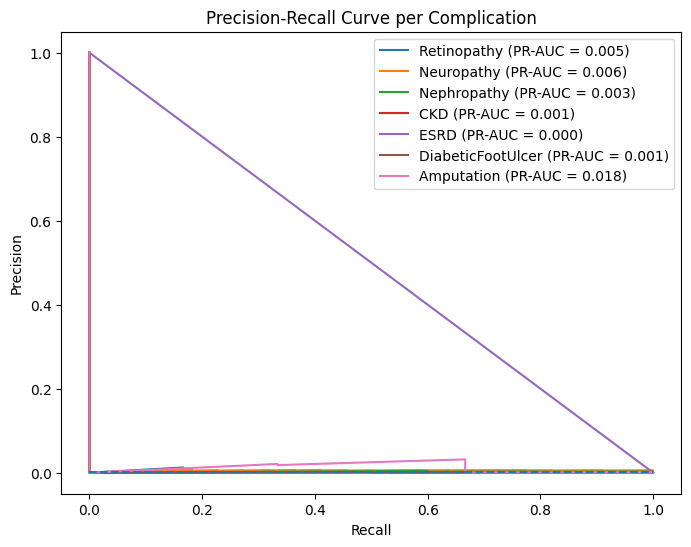

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

for i, label in enumerate(label_names):

    precision, recall, _ = precision_recall_curve(
        y_test_np[:, i],
        y_prob_np[:, i]
    )

    pr_auc = average_precision_score(
        y_test_np[:, i],
        y_prob_np[:, i]
    )

    plt.plot(
        recall,
        precision,
        label=f"{label} (PR-AUC = {pr_auc:.3f})"
    )


# optional baseline line (prevalence)
baseline = y_test_np.mean()
plt.hlines(
    baseline,
    xmin=0,
    xmax=1,
    linestyles="dashed"
)


plt.title("Precision-Recall Curve per Complication")

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.legend()

plt.show()

# Micro-average PR curve

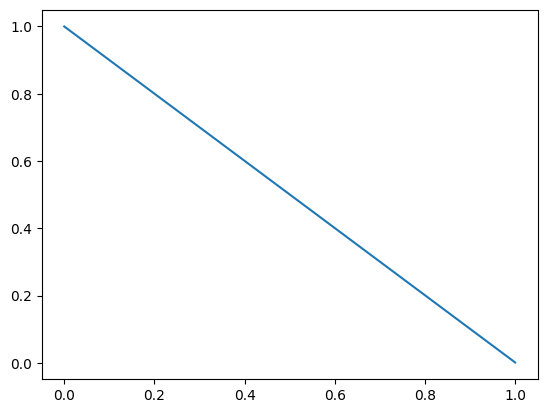

In [ ]:
precision, recall, _ = precision_recall_curve(
    y_test.ravel(),
    y_test_pred.ravel()
)

plt.plot(recall, precision)
plt.show()

# ROC Curve (per complication)

In [ ]:
y_prob_np = np.array(y_prob_matrix_test)


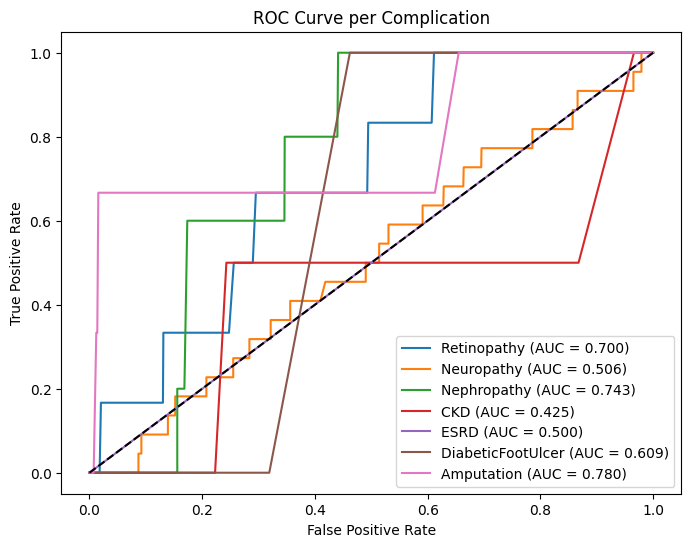

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

for i, label in enumerate(label_names):
    fpr, tpr, _ = roc_curve(y_test_np[:, i], y_prob_np[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{label} (AUC = {roc_auc:.3f})")

plt.plot([0,1], [0,1], 'k--')
plt.title("ROC Curve per Complication")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

# HyperParameter Tunning

In [ ]:
'''param_grid = {
    'model__estimator__n_estimators': [30, 50],
    'model__estimator__max_depth': [3, 5],
    'model__estimator__learning_rate': [0.01, 0.1],
    'model__estimator__subsample': [0.8, 1.0],
    'model__estimator__colsample_bytree': [0.8, 1.0]
}



search = RandomizedSearchCV(

    pipeline,

    param_distributions=param_grid,

    n_iter=5,          # NOT 10
    cv=3,              # NOT 5
    scoring= 'recall_macro',

    n_jobs=-1,          # MUST BE 1
    verbose=2,

    random_state=42

)

search.fit(X_sub, y_sub)'''

NameError: name 'X_sub' is not defined